<a href="https://colab.research.google.com/github/aditya0589/notebooks/blob/main/AI%20Engineering/Langchain/LC06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LC06 Agents and Tools**

## **Tools**

A tool is just a python function that is packed in a way that an LLM can understand and call when needed

Large Language Models are good at tasks like reasoning and content generation, but they cannot do tasks like accessing live data, doing reliable math, writing emails, calling APIs, writing code etc.

Using tools, we can enable the LLM to perform these tasks.


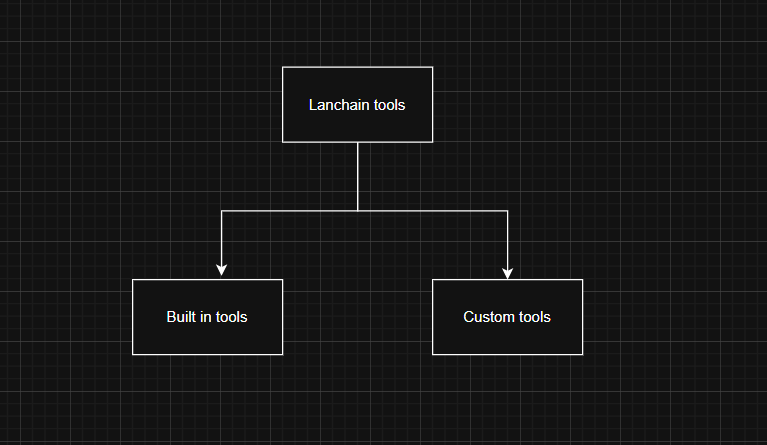

## **AI Agent**

An AI agent is an LLM powered system that can autonomously think, decide and take actions using external tools or APIs to achieve a task.



## **Langchain built in Tools**

A built in tool is a tool that langchain laready provides for you - its prebuilt, production ready and requires minimal or no setup.

You dont have to write the function logic yourself, you just import and use it.


`` DuckDuckGoSearchRun`` : Web search using DuckDuckGo

`` WikipediaQueryRun``: Wikipedia summary

` PythonREPLTool` : Run python scripts

` ShellTool` : run shell commands

` RequestGetTool` : Make HTTP GET requests

` GmailSendMessageTool`: send mails via GMail

` SlackSendMessageTool`: Post message to slack

`SQLDatabaseQueryTool`: query SQL databases

In [1]:
!pip install langchain langchain-core langchain-community pydantic duckduckgo-search langchain-experimental

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installe

In [2]:
import os
from google.colab import userdata

# Load keys from Colab Secrets
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
os.environ['HUGGINGFACEHUB_API_TOKEN'] = userdata.get('HUGGINGFACEHUB_API_TOKEN')

# Sanity check (safe partial print)
print("Groq:", os.environ["GROQ_API_KEY"][:8])
print("Google:", os.environ["GOOGLE_API_KEY"][:8])
print('HF_TOKEN', os.environ['HF_TOKEN'][:8])
print('huggingface api token', os.environ['HUGGINGFACEHUB_API_TOKEN'][:8])

Groq: gsk_L243
Google: AIzaSyCX
HF_TOKEN AIzaSyBE
huggingface api token hf_SMPRD


## How does Tools fit into the Agentic Ecosystem

An agent is an LLM powered system that can autonomously think, decide and take actions using external tools and APIs to achieve the goals.

The LLM is the brain of the Agent while tools are its body parts

## Built in Tools in Langchain

A built in tool is a tool that Langchain already provides for you. It is pre built, production-ready and requires minimal or no setup.


``DuckDuckGoSearchRun``: web search via DuckDuckGo

`` WikipediaQueryRun``: run wikipedia summary

`` PythonREPLTool``: Run Python scripts

`` ShellTool``: Run shell commands

``RequestGetTool``: Make HTTP GET requests

`` GmailSendMessageTool``: send message via Gmail

``SlackSendMessageTool``: post message via Slack

``SQLDatabaseQueryTool``: Run queries on SQL database

In [3]:
pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 5.9 MB/s eta 0:00:00


The below Code snippet shows how we use Langchain tool to perform web search using DuckDuckGo

In [4]:
from langchain_community.tools import DuckDuckGoSearchRun
search_tool = DuckDuckGoSearchRun()

results = search_tool.invoke("Trump Iran blockade")

print(results)

The blockade, which began a week ago, is "absolutely destroying Iran", Trump wrote on his social media platform Truth Social, adding his country was winning the conflict "by a lot". Over a month into a war with Iran that has no clear end, President Trump has enforced a blockade, which went into effect on Monday at the Strait of Hormuz. President Donald Trump announced the United States would apply its own blockade of the Strait of Hormuz in retaliation for Iran's de facto shutdown, which is now stretching into its seventh... Donald Trump announces a full blockade of Iranian ports after failed U.S.-Iran talks, but key allies refuse to back the move. Britain rejects participation President Trump said he’s extended the ceasefire with Iran until Tehran has submitted a proposal to end the conflict permanently. He said the US would continue to blockade Iranian ports.


The below code snippet executes shell commands using tool

In [5]:
from langchain_community.tools import ShellTool

shell_tool = ShellTool()

result = shell_tool.invoke('ls')
print(result)

Executing command:
 ls
sample_data



/usr/local/lib/python3.12/dist-packages/langchain_community/tools/shell/tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


## Custom Tools

Custom tools are the tools you define yourself:

You use them when:
1. You want to call your own APIs
2. You want to encapsulate business logic
3. You want the LLM to interact with your database, product or app.

In [6]:
from langchain_core.tools import tool

In [7]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers"""
    return a * b

In [8]:
result = multiply.invoke({"a": 10, "b": 2})
print(result)

20


In [9]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Multiplies two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


## Creating Custom Tools

There are various ways to create custom tools in Langchain

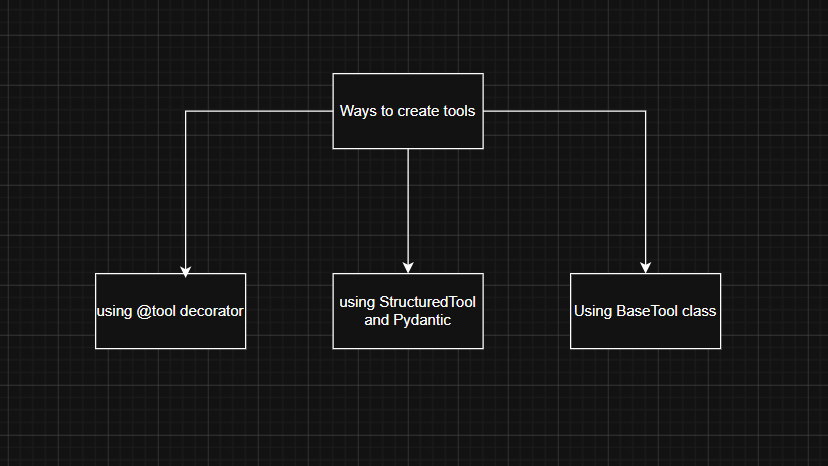

## StructuredTool

A structured tool in langchain is a special type of tool where the input of the tool followins a structured schema, typically defined using a Pydantic model

In [10]:
from langchain_core.tools import StructuredTool
from pydantic import BaseModel, Field

In [11]:
class Multiply(BaseModel):
  a: int = Field(required=True, description="first number to add")
  b: int = Field(required=True, description="second number to add")

/tmp/ipykernel_1678/2042688281.py:2: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  a: int = Field(required=True, description="first number to add")
/tmp/ipykernel_1678/2042688281.py:3: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  b: int = Field(required=True, description="second number to add")


In [12]:
def multiply_func(a: int, b: int) -> int:
  """ returns the product of two numbers"""
  return a * b

In [13]:
multiply_tool = StructuredTool.from_function(
    func = multiply_func,
    name = 'multiply_func',
    description="multiply two numbers",
    args_schema = Multiply
)

In [14]:
result = multiply_tool.invoke({'a': 5, 'b': 4})
print(result)

20


## Using **BaseTool** class

BaseTool is the abstract base class for all tools in Langchain. It defines the core structure and interface that any toolmust follow, whether its asimple one-liner or a fully customized function.

All other tool types like @tool or StructuredTool are built on top of BaseTool

In [15]:
from langchain_core.tools import BaseTool
from typing import Type

In [16]:
class MultiplyInput(BaseModel):
  a: int = Field(required=True, description='First number to be multiplied')
  b: int = Field(required=True, description="Second number to be multiplied")



/tmp/ipykernel_1678/3332165460.py:2: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  a: int = Field(required=True, description='First number to be multiplied')
/tmp/ipykernel_1678/3332165460.py:3: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  b: int = Field(required=True, description="Second number to be multiplied")


In [17]:
class MultiplyTool(BaseTool):
  name: str = 'Multiply'
  description: str = "Multiply two numbers"

  arge_schema: Type[BaseModel] = MultiplyInput

  def _run(self, a: int, b: int) -> int:
    return a * b

In [18]:
multiply_tool = MultiplyTool()

In [19]:
result = multiply_tool.invoke({'a': 5, 'b': 4})

print(result)

20


## Toolkits

A toolkit is a collection (bundle) of related tools that serve a common purpose. packaged together for convinience and reusability.

in Langchain:
 A toolkit might be: GoogleDriveToolKit
and it can contain the following tools

1. ``GoogleDriveCreateFileTool``: Upload a file
2. `` GoogleDriveSearchTool``: search for a file by name/content
3. `` GoogleDriveReadFileTool``: Read contents of a file

In [20]:
from langchain_core.tools import tool

In [21]:
@tool
def add(a: int, b:int) -> int:
  """Adds two numbers"""
  return a + b

In [22]:
@tool
def multiply(a: int, b:int) -> int:
  """Multiplies two numbers"""
  return a * b

In [23]:
class MathToolKit:
  def get_tools(self):
    return [add, multiply]

In [24]:
tools = MathToolKit()
tools = tools.get_tools()

In [25]:
for tool in tools:
  print(tool.name)
  print(tool.description)

add
Adds two numbers
multiply
Multiplies two numbers


# **Langchain Tool Calling**

## Tool Binding
Tool binding is the step where you register tools with a language model (LLM) so that:
1. the LLM knows what tools are available
2. It knows what each tools does(via description)
3. It knows what input format to use(via schema)





First we create a tool

In [26]:
!pip install langchain_groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.7 MB/s eta 0:00:00


In [27]:
from langchain_core.tools import tool
from langchain_groq import ChatGroq

In [28]:
@tool
def multiply(a: int, b: int) -> int:
  """Multiplies two numbers"""
  return a * b

In [34]:
llm = ChatGroq(model_name='openai/gpt-oss-120b')
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7c5ffd0efa10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7c5ffd0eeff0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [35]:
llm_with_tools = llm.bind_tools([multiply])

In [36]:
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7c5ffd0efa10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7c5ffd0eeff0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiplies two numbers', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}]}, config={}, config_factories=[])

Now the LLM has the tool with it to be used whenever needed

## Tool Calling

Tool calling is the process where the LLM (language model) decides, during a conversation or task, that it needs to use a specific tool - and generates a structured output with:
1. the name of the tool
2. the arguments to call it with


Note: The LLM does not actually run the tool, it just suggests the tool and its input arguments, the actual execution is handled by Langchainor the programmer.

In [37]:
llm_with_tools.invoke("Hi how are you?")

AIMessage(content="Hello! I'm doing great, thank you for asking. How can I assist you today?", additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "Hi how are you?" We can respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 127, 'total_tokens': 177, 'completion_time': 0.104280191, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.005069945, 'prompt_tokens_details': None, 'queue_time': 0.023284393, 'total_time': 0.109350136}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_df9620fe21', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e06d5-1941-71e1-a95f-93888020553e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 127, 'output_tokens': 50, 'total_tokens': 177, 'output_token_details': {'reasoning': 23}})

For the above query, the LLM need not use any tool. Thats why no tool has been called.

In [38]:
llm_with_tools.invoke('can you multiply 3 with 10?')

AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks to multiply 3 with 10. Use multiply function.', 'tool_calls': [{'id': 'fc_1fe29ddc-9e24-4421-9844-ef599695eaab', 'function': {'arguments': '{"a":3,"b":10}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 131, 'total_tokens': 179, 'completion_time': 0.101201151, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.005326645, 'prompt_tokens_details': None, 'queue_time': 0.047627524, 'total_time': 0.106527796}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e1a42825ac', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e06d6-b80c-7933-b0ce-1d6c004981e5-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 10}, 'id': 'fc_1fe29ddc-9e24-4421-9844-ef599695eaab', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1

Now you can find that for the multiplication operation, the LLM is calling the multiplication tool

In [39]:
llm_with_tools.invoke('can you multiply 3 with 10?').tool_calls[0]

{'name': 'multiply',
 'args': {'a': 3, 'b': 10},
 'id': 'fc_0e17b594-4152-418c-90c1-9b8b9707b258',
 'type': 'tool_call'}

We can find the details of the tool call, the name of the tool, the parameters that must be passed for the tool etc

## Tool Execution

Tool Execution is the step where the actual python function(tool) is run using the input arguments that the LLM suggested during tool calling.


In [41]:
result = llm_with_tools.invoke('can you multiply 3 with 10?')

In [45]:
result2 = multiply.invoke(result.tool_calls[0]['args'])
print(result2)

30


This is how we can execute the tools with the parameters provided by the LLM

But instead of sending just the arguments as parameters to the tool, we can send the entire tool call result to get a special output called the `` ToolMessage``

In [46]:
multiply.invoke(result.tool_calls[0])

ToolMessage(content='30', name='multiply', tool_call_id='fc_89e8f153-7f0b-4f12-920f-5a5f9f359522')

This `toolMessage` can be again passed to the LLM to get the response, making it a chain like structure for complex tasks

In order to get LLM response for tool calls as an agentic system, we need ensure memory (a list contains all previous messages). this memory must be passed to the LLM